In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


li=pd.read_csv("/content/listings.csv")
nig=pd.read_csv("/content/neighbourhoods.csv")
rev=pd.read_csv("/content/reviews.csv")
li.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,155305,Cottage! BonPaul + Sharky's Hostel,746673,BonPaul,NaN,28806,35.578640,-82.595780,Entire home/apt,95.0,1,454,2025-06-14,2.69,8,162,16,NaN
1,197263,Tranquil Room & Private Bath,961396,Timothy,NaN,28806,35.577350,-82.638040,Private room,44.0,2,87,2024-09-08,0.56,2,73,5,NaN
2,209068,Terrace Cottage,1029919,Kevin,NaN,28804,35.617641,-82.551819,Entire home/apt,90.0,30,67,2025-05-03,0.40,1,268,2,NaN
3,246315,Asheville Dreamer's Cabin,1292070,Annie,NaN,28805,35.596150,-82.506350,Private room,61.0,7,53,2019-10-30,0.32,3,62,0,NaN
4,314540,Asheville Urban Farmhouse Entire Home 4.6 mi t...,381660,Tom,NaN,28806,35.585610,-82.627310,Entire home/apt,200.0,1,35,2025-06-13,0.22,1,139,11,NaN


In [ ]:
li.shape

(2876, 18)

In [ ]:
li.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2876 entries, 0 to 2875
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              2876 non-null   int64  
 1   name                            2876 non-null   object 
 2   host_id                         2876 non-null   int64  
 3   host_name                       2876 non-null   object 
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   2876 non-null   int64  
 6   latitude                        2876 non-null   float64
 7   longitude                       2876 non-null   float64
 8   room_type                       2876 non-null   object 
 9   price                           2536 non-null   float64
 10  minimum_nights                  2876 non-null   int64  
 11  number_of_reviews               2876 non-null   int64  
 12  last_review                     26

In [ ]:
li.drop(columns=["neighbourhood_group","license"],axis=1,inplace=True)

In [ ]:
li.shape

(2876, 16)

In [ ]:
li.drop(columns=["latitude","longitude"],axis=1,inplace=True)

In [ ]:
li.head()

,id,name,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,155305,Cottage! BonPaul + Sharky's Hostel,746673,BonPaul,28806,Entire home/apt,95.0,1,454,2025-06-14,2.69,8,162,16
1,197263,Tranquil Room & Private Bath,961396,Timothy,28806,Private room,44.0,2,87,2024-09-08,0.56,2,73,5
2,209068,Terrace Cottage,1029919,Kevin,28804,Entire home/apt,90.0,30,67,2025-05-03,0.40,1,268,2
3,246315,Asheville Dreamer's Cabin,1292070,Annie,28805,Private room,61.0,7,53,2019-10-30,0.32,3,62,0
4,314540,Asheville Urban Farmhouse Entire Home 4.6 mi t...,381660,Tom,28806,Entire home/apt,200.0,1,35,2025-06-13,0.22,1,139,11


In [ ]:
li.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood,0
room_type,0
price,340
minimum_nights,0
number_of_reviews,0
last_review,263


In [ ]:
li["price"].describe()

,price
count,2536.000000
mean,181.261435
std,222.095805
min,18.000000
25%,90.000000
50%,128.000000
75%,204.000000
max,6846.000000


<Axes: ylabel='price'>

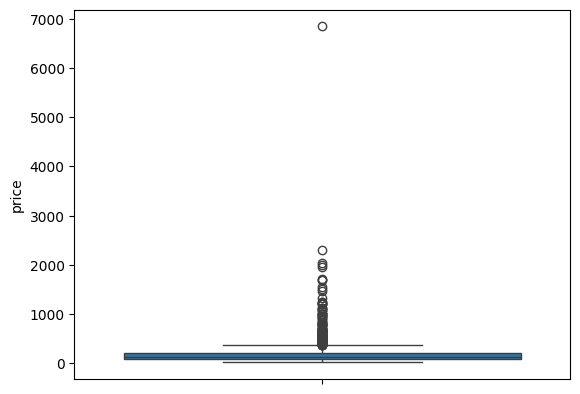

In [ ]:
sns.boxplot(data=li,y=li["price"])

### Handling Missing Values and Outliers in 'price' column

In [ ]:
li['price'].fillna(li['price'].median(),inplace=True)
print(f"Missing values in 'price' after imputation: {li['price'].isnull().sum()}")

Missing values in 'price' after imputation: 0


In [ ]:
# Calculate Q1, Q3, and IQR
Q1 = li['price'].quantile(0.25)
Q3 = li['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
li = li[(li['price'] >= lower_bound) & (li['price'] <= upper_bound)]
print(f"DataFrame shape after removing price outliers: {li.shape}")

DataFrame shape after removing price outliers: (2633, 14)


,price
count,2633.000000
mean,135.350171
std,62.432788
min,18.000000
25%,91.000000
50%,128.000000
75%,163.000000
max,332.000000


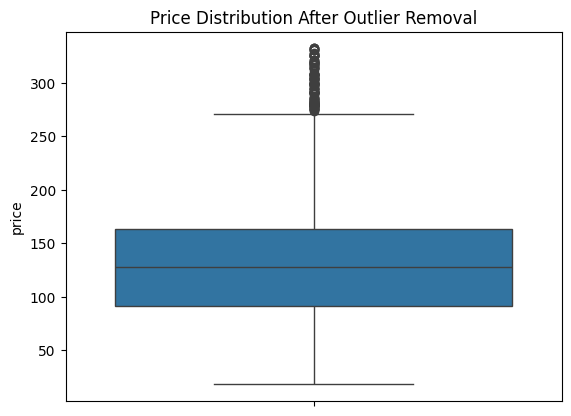

In [ ]:
# Display description of price column after cleaning
display(li['price'].describe())

# Display boxplot after cleaning
sns.boxplot(data=li,y=li['price'])
plt.title('Price Distribution After Outlier Removal')
plt.show()

<Axes: >

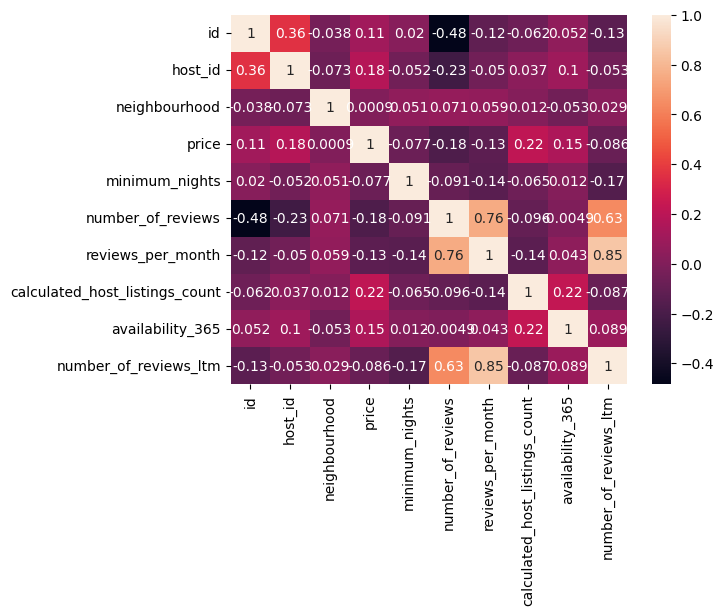

In [ ]:
sns.heatmap(data=li.corr(numeric_only=True),annot=True)

In [ ]:
li.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2633 entries, 0 to 2875
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              2633 non-null   int64  
 1   name                            2633 non-null   object 
 2   host_id                         2633 non-null   int64  
 3   host_name                       2633 non-null   object 
 4   neighbourhood                   2633 non-null   int64  
 5   room_type                       2633 non-null   object 
 6   price                           2633 non-null   float64
 7   minimum_nights                  2633 non-null   int64  
 8   number_of_reviews               2633 non-null   int64  
 9   last_review                     2410 non-null   object 
 10  reviews_per_month               2410 non-null   float64
 11  calculated_host_listings_count  2633 non-null   int64  
 12  availability_365                2633 no

In [ ]:
li["last_review"]=pd.to_datetime(li["last_review"])

In [ ]:
li["last_review"].isnull().sum()

np.int64(223)

In [ ]:
li["last_review"]=li["last_review"].fillna(method="ffill")

In [ ]:
li["last_review"].shape

(2633,)

In [ ]:
li["reviews_per_month"].describe()

,reviews_per_month
count,2410.000000
mean,2.211365
std,2.034731
min,0.020000
25%,0.660000
50%,1.650000
75%,3.150000
max,19.960000


In [ ]:
q1=li["reviews_per_month"].quantile(0.25)
q3=li["reviews_per_month"].quantile(0.75)
iqr=q3-q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

In [ ]:
li=li[(li["reviews_per_month"]>=lower_bound) & (li["reviews_per_month"]<=upper_bound)]


In [ ]:
li["last_review"]=li["last_review"].fillna(li["last_review"].mode()[0])

In [ ]:
li.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2325 entries, 0 to 2858
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              2325 non-null   int64         
 1   name                            2325 non-null   object        
 2   host_id                         2325 non-null   int64         
 3   host_name                       2325 non-null   object        
 4   neighbourhood                   2325 non-null   int64         
 5   room_type                       2325 non-null   object        
 6   price                           2325 non-null   float64       
 7   minimum_nights                  2325 non-null   int64         
 8   number_of_reviews               2325 non-null   int64         
 9   last_review                     2325 non-null   datetime64[ns]
 10  reviews_per_month               2325 non-null   float64       
 11  calculate

In [ ]:
li.duplicated().sum()

np.int64(0)

In [ ]:
li["availability_365"].value_counts()

,count
availability_365,
0,156
365,51
364,30
347,29
167,23
...,...
88,1
20,1
24,1


<Axes: xlabel='room_type', ylabel='Count'>

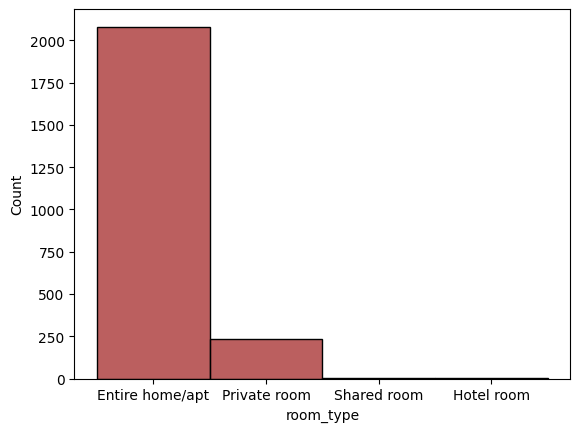

In [ ]:
# distribution

sns.histplot(data=li,x="room_type",color="brown")

In [ ]:
li.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2325 entries, 0 to 2858
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              2325 non-null   int64         
 1   name                            2325 non-null   object        
 2   host_id                         2325 non-null   int64         
 3   host_name                       2325 non-null   object        
 4   neighbourhood                   2325 non-null   int64         
 5   room_type                       2325 non-null   object        
 6   price                           2325 non-null   float64       
 7   minimum_nights                  2325 non-null   int64         
 8   number_of_reviews               2325 non-null   int64         
 9   last_review                     2325 non-null   datetime64[ns]
 10  reviews_per_month               2325 non-null   float64       
 11  calculate

In [ ]:
#Count the number of active listings per neighborhood.
li["neighbourhood"].unique()


array([28806, 28804, 28805, 28803, 28801, 28704, 28732, 28715])

In [ ]:
li.head(10)

,id,name,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
0,155305,Cottage! BonPaul + Sharky's Hostel,746673,BonPaul,28806,Entire home/apt,95.0,1,454,2025-06-14,2.69,8,162,16
1,197263,Tranquil Room & Private Bath,961396,Timothy,28806,Private room,44.0,2,87,2024-09-08,0.56,2,73,5
2,209068,Terrace Cottage,1029919,Kevin,28804,Entire home/apt,90.0,30,67,2025-05-03,0.40,1,268,2
3,246315,Asheville Dreamer's Cabin,1292070,Annie,28805,Private room,61.0,7,53,2019-10-30,0.32,3,62,0
4,314540,Asheville Urban Farmhouse Entire Home 4.6 mi t...,381660,Tom,28806,Entire home/apt,200.0,1,35,2025-06-13,0.22,1,139,11
5,427497,Luxurious Mountain Guest Suite Apartment,1909922,Milan,28803,Entire home/apt,148.0,2,47,2023-09-04,0.31,1,362,0
6,436476,"8 min Walk to DT AVL! Hip, Chic % Sparkling CLEAN",478398,Heidi,28801,Entire home/apt,128.0,2,410,2024-06-26,2.58,3,0,1
7,483384,"Romantic, Moroccan-Influenced Cottage",467421,Camille,28806,Entire home/apt,107.0,1,820,2025-06-14,6.28,2,293,44
8,483396,Frida Inspired Home,467421,Camille,28806,Entire home/apt,143.0,2,70,2015-10-03,0.44,2,224,0
9,621243,The Birdhouse\nSweet suite! Downtown Roof top ...,3079174,Molly,28801,Entire home/apt,143.0,30,146,2024-08-21,1.66,1,256,4


In [ ]:
nig.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   neighbourhood_group  0 non-null      float64
 1   neighbourhood        8 non-null      int64  
dtypes: float64(1), int64(1)
memory usage: 260.0 bytes


In [ ]:
nig.head()

,neighbourhood_group,neighbourhood
0,NaN,28704
1,NaN,28715
2,NaN,28732
3,NaN,28801
4,NaN,28803


In [ ]:
nig["neighbourhood"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 8 entries, 0 to 7
Series name: neighbourhood
Non-Null Count  Dtype
--------------  -----
8 non-null      int64
dtypes: int64(1)
memory usage: 196.0 bytes


In [ ]:
ni=pd.merge(li, nig, on="neighbourhood")

In [ ]:
ni.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2325 entries, 0 to 2324
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              2325 non-null   int64         
 1   name                            2325 non-null   object        
 2   host_id                         2325 non-null   int64         
 3   host_name                       2325 non-null   object        
 4   neighbourhood                   2325 non-null   int64         
 5   room_type                       2325 non-null   object        
 6   price                           2325 non-null   float64       
 7   minimum_nights                  2325 non-null   int64         
 8   number_of_reviews               2325 non-null   int64         
 9   last_review                     2325 non-null   datetime64[ns]
 10  reviews_per_month               2325 non-null   float64       
 11  calc

In [ ]:
ni.drop(columns=["neighbourhood_group"],inplace=True)

<Axes: xlabel='neighbourhood', ylabel='price'>

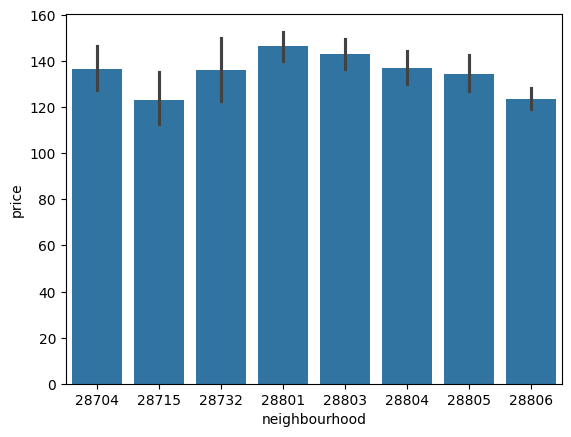

In [ ]:
#Compare average price by neighborhood (use neighbourhood field)

sns.barplot(data=ni,x="neighbourhood",y="price",estimator="mean")

In [ ]:
#Identify the top 5 most expensive neighborhoods.
axx=ni.groupby("price")["neighbourhood"].max().sort_values(ascending=False).head()
axx


,neighbourhood
price,
328.0,28806
18.0,28806
20.0,28806
21.0,28806
22.0,28806


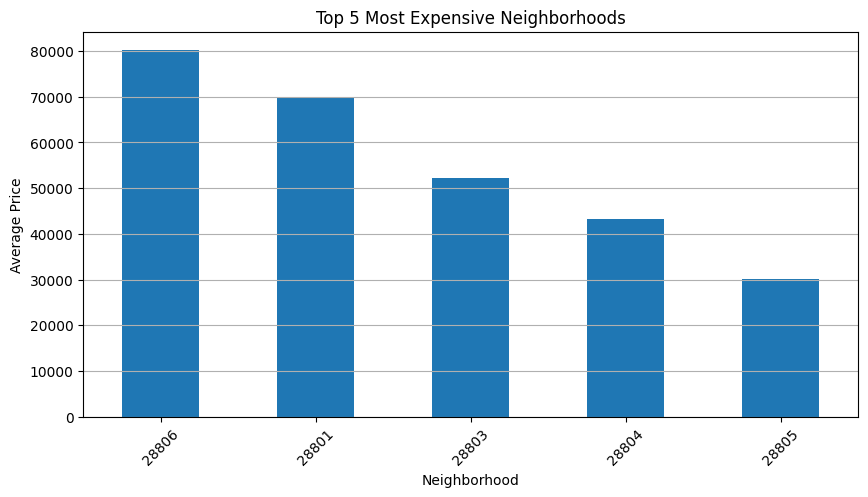

In [ ]:


# Top 5 most expensive neighborhoods based on average price
axx = ni.groupby("neighbourhood")["price"].sum().sort_values(ascending=False).head(5)

# Plot
plt.figure(figsize=(10,5))
axx.plot(kind="bar")

plt.title("Top 5 Most Expensive Neighborhoods")
plt.xlabel("Neighborhood")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

In [ ]:
rev.head()

,listing_id,date
0,155305,2011-07-31
1,155305,2011-08-23
2,155305,2011-09-19
3,155305,2011-10-28
4,155305,2012-07-01


In [ ]:
ni.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood', 'room_type',
       'price', 'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm'],
      dtype='object')

In [ ]:
# Check if minimum nights affect average price.
ni.groupby("minimum_nights")["price"].mean()


,price
minimum_nights,
1,129.590969
2,138.909528
3,162.555066
4,160.769231
5,148.416667
7,97.625000
8,145.500000
9,143.000000
10,115.000000


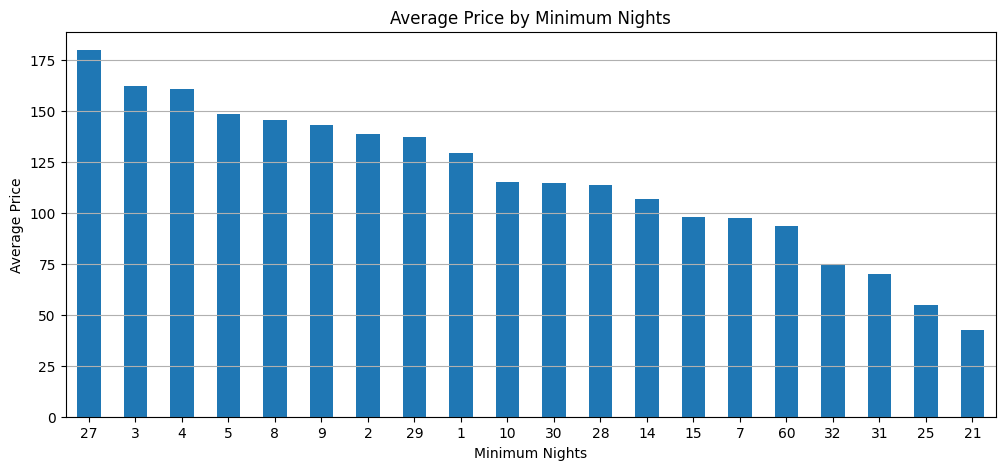

In [ ]:
# Top minimum nights values only
avg_price = ni.groupby("minimum_nights")["price"].mean().head(20).sort_values(ascending=False)

# Plot
plt.figure(figsize=(12,5))
avg_price.plot(kind="bar")

plt.title("Average Price by Minimum Nights")
plt.xlabel("Minimum Nights")
plt.ylabel("Average Price")
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()

In [ ]:
#Find the hosts with the most listings (calculated_host_listings_count).

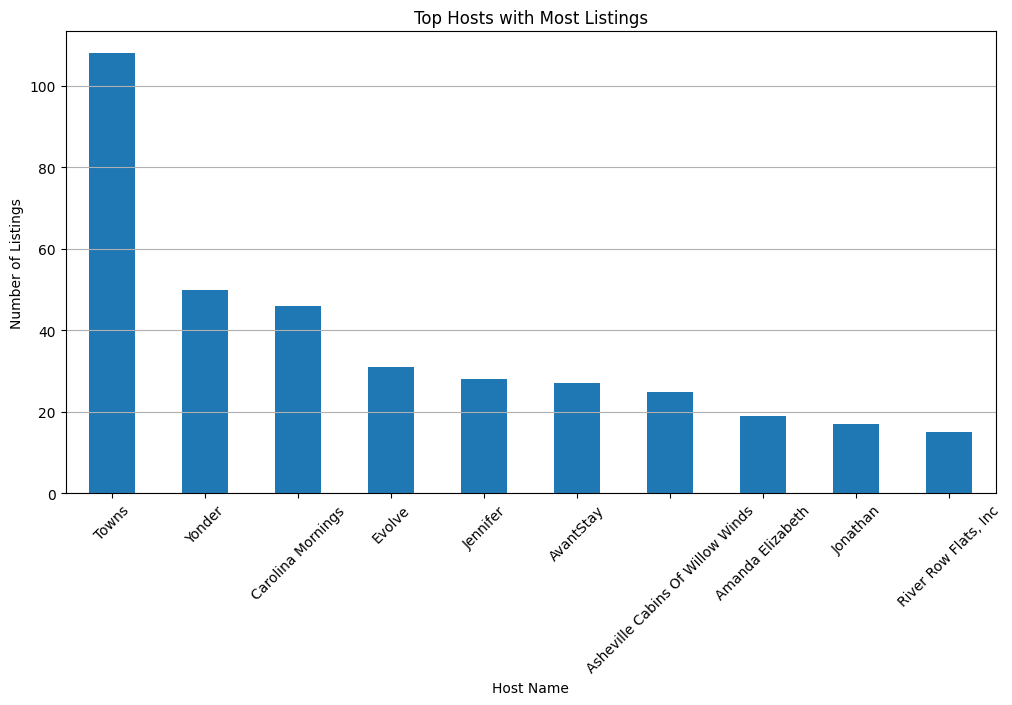

In [ ]:
import matplotlib.pyplot as plt

# Hosts with the most listings
top_hosts = ni.groupby("host_name")["calculated_host_listings_count"] \
              .max() \
              .sort_values(ascending=False) \
              .head(10)

# Plot
plt.figure(figsize=(12,6))
top_hosts.plot(kind="bar")

plt.title("Top Hosts with Most Listings")
plt.xlabel("Host Name")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

** Here’s what you should do:
1. Data Preparation

Inspect each dataset and check for missing values (e.g., neighbourhood_group is blank).

Look for outliers in price (e.g., very low or very high nightly rates).

Merge reviews.csv with listings.csv to connect review activity to listing details.

2. Descriptive Analysis

Calculate the average and median nightly price for all listings.

Show the distribution of room types (Entire home, Private room, Shared room).

Count the number of active listings per neighborhood.

3. Pricing Insights

Compare average price by neighborhood (use neighbourhood field).

Identify the top 5 most expensive neighborhoods.

Check if minimum nights affect average price.

4. Review & Demand Analysis

Calculate the total number of reviews per listing and the average reviews per month.

Identify which neighborhoods generate the most guest activity.

Look at trends in reviews.csv → which years/months had spikes in demand?

5. Host Analysis

Find the hosts with the most listings (calculated_host_listings_count).

Compare Superhosts vs. non-Superhosts (if data available).

Check whether hosts with multiple listings charge higher or lower average prices.

6. Recommendations

Based on the data, suggest whether Asheville is a good expansion market.

Highlight specific neighborhoods or property types with strong opportunity.

**

In [ ]:
# Descriptive Analysis
# Calculate the average and median nightly price for all listings.

# Show the distribution of room types (Entire home, Private room, Shared room).

# Count the number of active listings per neighborhood.





Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood', 'room_type',
       'price', 'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm'],
      dtype='object')

Average Nightly Price (All Listings): $135.35
Median Nightly Price (All Listings): $128.00


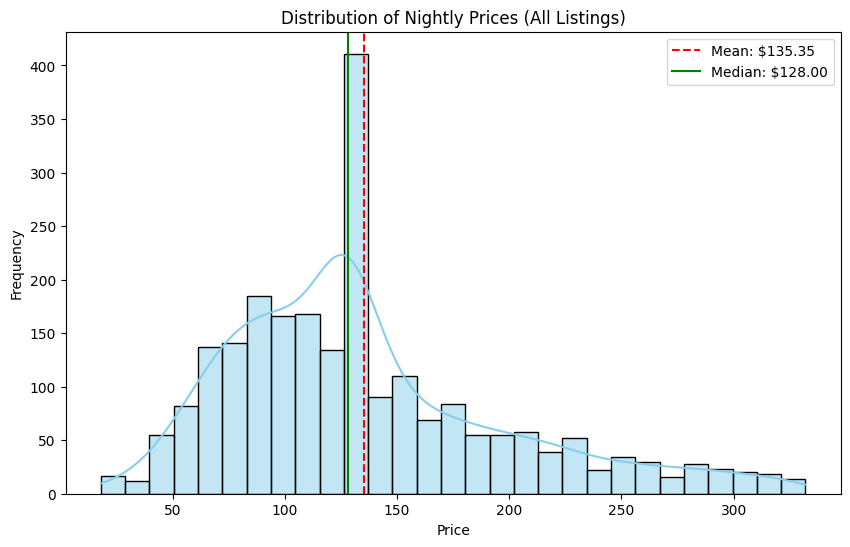

In [ ]:
overall_avg = ni['price'].mean()
overall_median = ni['price'].median()

print(f"Average Nightly Price (All Listings): ${overall_avg:.2f}")
print(f"Median Nightly Price (All Listings): ${overall_median:.2f}")

# Visualization of the overall price distribution
plt.figure(figsize=(10, 6))
sns.histplot(ni['price'], kde=True, color='skyblue')
plt.axvline(overall_avg, color='red', linestyle='--', label=f'Mean: ${overall_avg:.2f}')
plt.axvline(overall_median, color='green', linestyle='-', label=f'Median: ${overall_median:.2f}')
plt.title('Distribution of Nightly Prices (All Listings)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.legend()
plt.show()

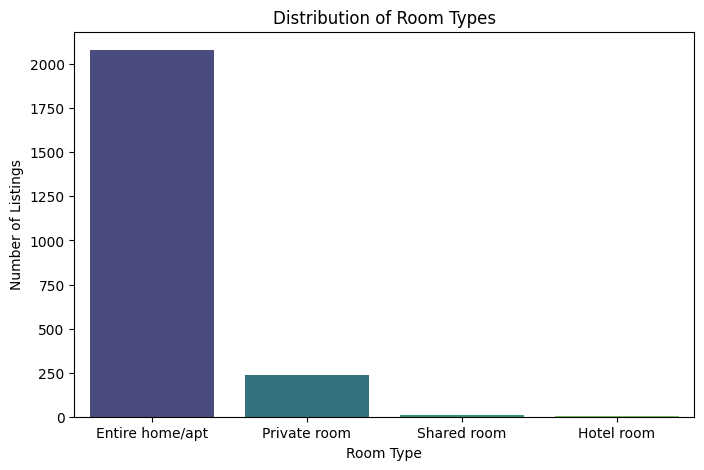

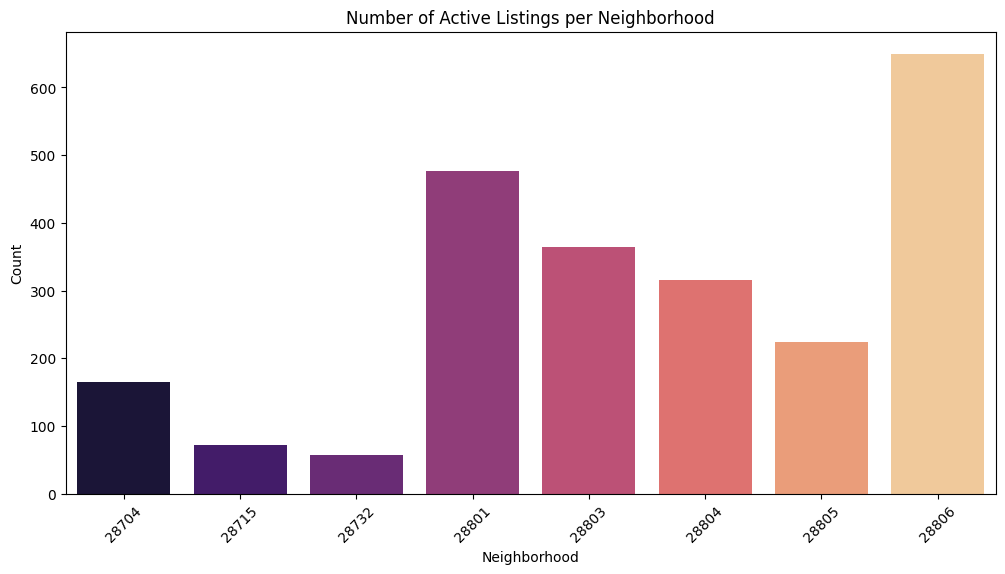

Listings per neighborhood:
   neighbourhood  listing_count
0          28806            650
1          28801            477
2          28803            364
3          28804            316
4          28805            224
5          28704            165
6          28715             72
7          28732             57


In [ ]:
# Show the distribution of room types
plt.figure(figsize=(8, 5))
sns.countplot(data=ni, x='room_type', palette='viridis')
plt.title('Distribution of Room Types')
plt.xlabel('Room Type')
plt.ylabel('Number of Listings')
plt.show()

# Count the number of active listings per neighborhood
listings_per_neighborhood = ni['neighbourhood'].value_counts().reset_index()
listings_per_neighborhood.columns = ['neighbourhood', 'listing_count']

plt.figure(figsize=(12, 6))
sns.barplot(data=listings_per_neighborhood, x='neighbourhood', y='listing_count', palette='magma')
plt.title('Number of Active Listings per Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

print("Listings per neighborhood:")
print(listings_per_neighborhood)

### 3. Pricing Insights
In this section, we analyze how location and booking requirements (minimum nights) influence the nightly price.

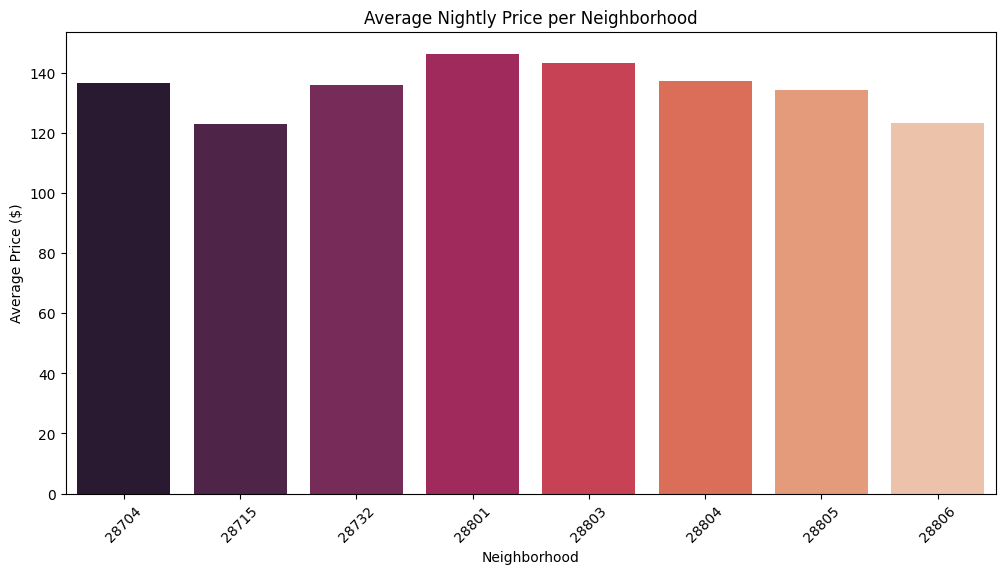

Top 5 Most Expensive Neighborhoods (Average Price):
   neighbourhood       price
0          28801  146.356394
1          28803  143.206044
2          28804  137.085443
3          28704  136.478788
4          28732  135.947368


In [ ]:
# Compare average price by neighborhood
neighborhood_prices = ni.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=neighborhood_prices, x='neighbourhood', y='price', palette='rocket')
plt.title('Average Nightly Price per Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45)
plt.show()

# Identify the top 5 most expensive neighborhoods
top_5_expensive = neighborhood_prices.head(5)
print("Top 5 Most Expensive Neighborhoods (Average Price):")
print(top_5_expensive)

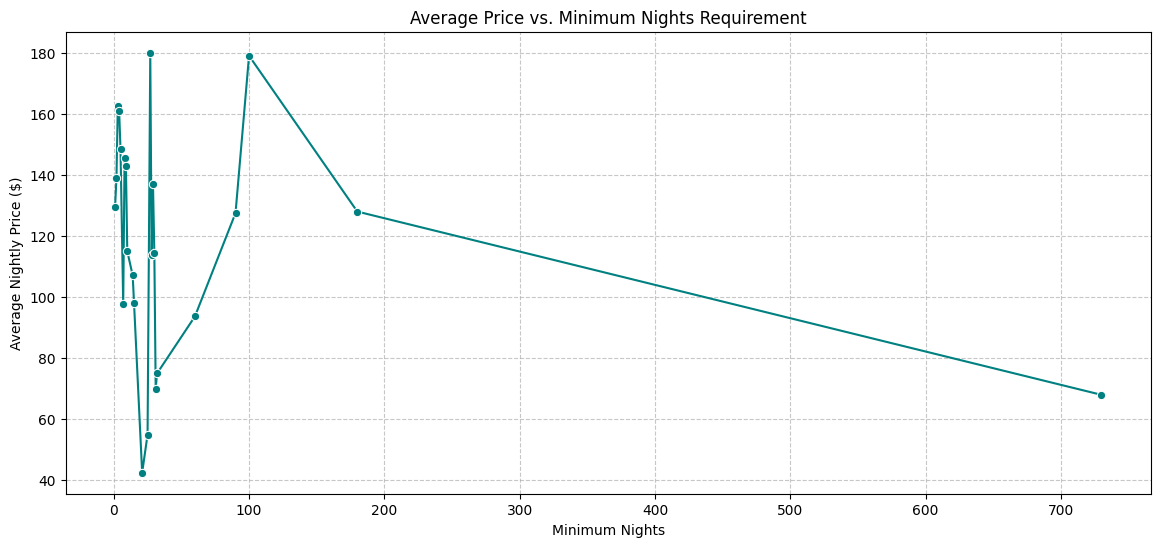

Correlation between Minimum Nights and Price: -0.0687


In [ ]:
# Check if minimum nights affect average price
min_nights_price = ni.groupby('minimum_nights')['price'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=min_nights_price, x='minimum_nights', y='price', marker='o', color='teal')
plt.title('Average Price vs. Minimum Nights Requirement')
plt.xlabel('Minimum Nights')
plt.ylabel('Average Nightly Price ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Correlation check
correlation = ni['minimum_nights'].corr(ni['price'])
print(f"Correlation between Minimum Nights and Price: {correlation:.4f}")

### 4. Review & Demand Analysis
In this section, we analyze guest activity and demand trends based on the number of reviews.

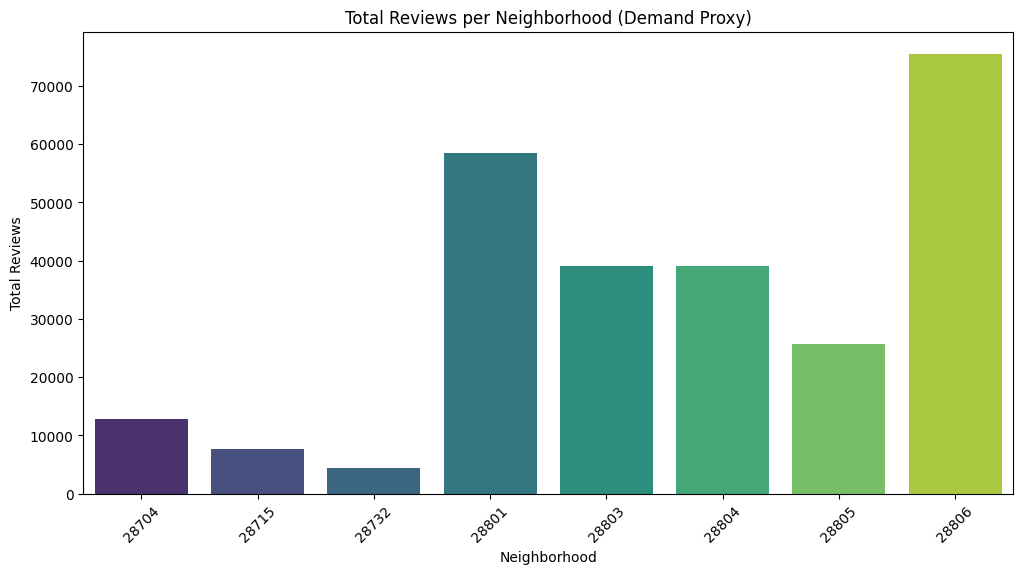

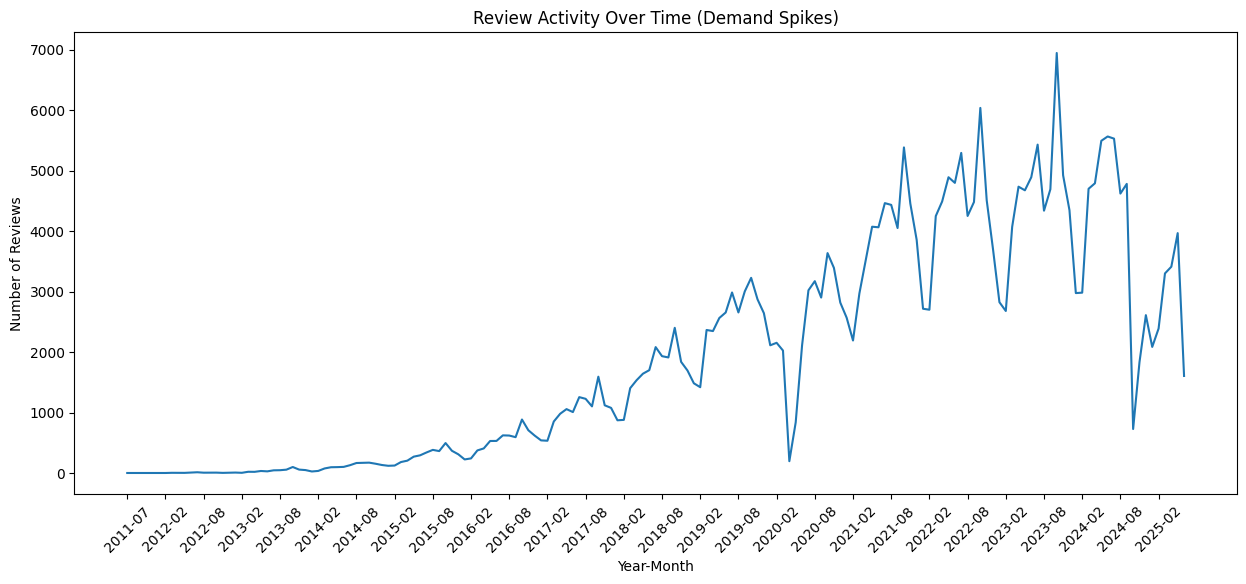

In [ ]:
# 1. Total reviews per listing and average reviews per month are already in the 'ni' dataframe.
# Let's identify which neighborhoods generate the most guest activity (total reviews).
neighborhood_demand = ni.groupby('neighbourhood')['number_of_reviews'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=neighborhood_demand, x='neighbourhood', y='number_of_reviews', palette='viridis')
plt.title('Total Reviews per Neighborhood (Demand Proxy)')
plt.xlabel('Neighborhood')
plt.ylabel('Total Reviews')
plt.xticks(rotation=45)
plt.show()

# 2. Time-based trends using reviews.csv
rev['date'] = pd.to_datetime(rev['date'])
rev['year'] = rev['date'].dt.year
rev['month'] = rev['date'].dt.month

# Group by year and month to see activity over time
monthly_reviews = rev.groupby(['year', 'month']).size().reset_index(name='review_count')
monthly_reviews['date_str'] = monthly_reviews['year'].astype(str) + '-' + monthly_reviews['month'].astype(str).str.zfill(2)

plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_reviews, x='date_str', y='review_count')
plt.title('Review Activity Over Time (Demand Spikes)')
plt.xlabel('Year-Month')
plt.ylabel('Number of Reviews')
plt.xticks(monthly_reviews['date_str'][::6], rotation=45)
plt.show()

### 5. Host Analysis
Exploring host behavior and its relationship with pricing and market share.

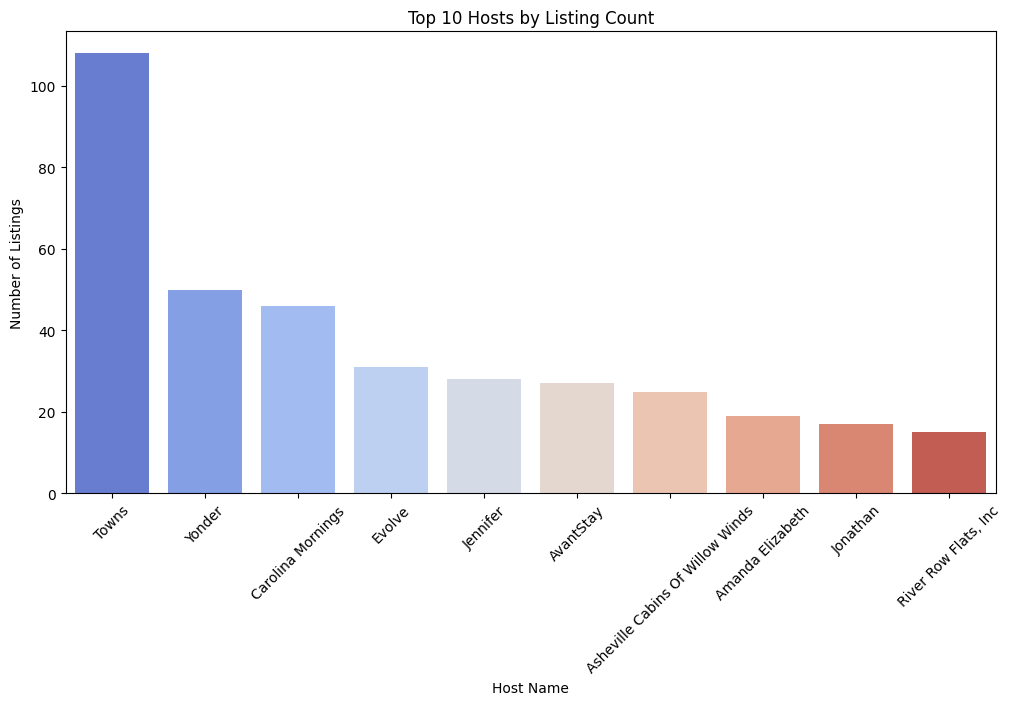

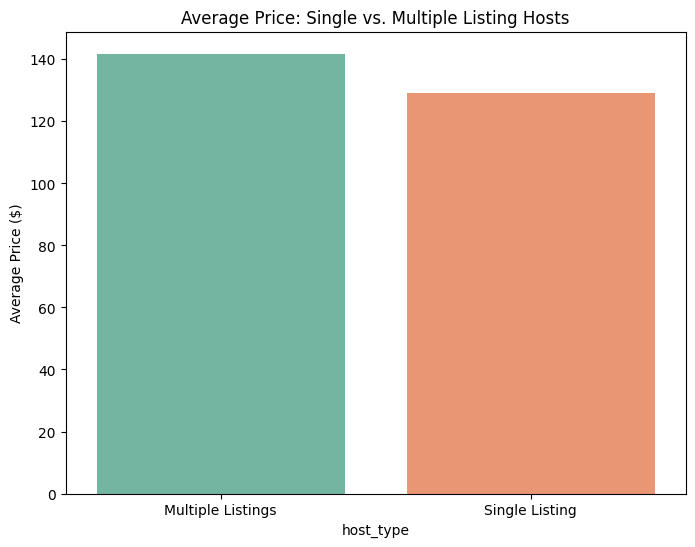

Average price by host type:
           host_type       price
0  Multiple Listings  141.803819
1     Single Listing  129.002558


In [ ]:
# Identify top hosts by count of listings
top_hosts_count = ni.groupby('host_name')['calculated_host_listings_count'].max().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=top_hosts_count, x='host_name', y='calculated_host_listings_count', palette='coolwarm')
plt.title('Top 10 Hosts by Listing Count')
plt.xlabel('Host Name')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.show()

# Check whether hosts with multiple listings charge higher or lower average prices
# We'll create a category for 'Single Listing' vs 'Multiple Listings'
ni['host_type'] = ni['calculated_host_listings_count'].apply(lambda x: 'Single Listing' if x == 1 else 'Multiple Listings')

host_type_price = ni.groupby('host_type')['price'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=host_type_price, x='host_type', y='price', palette='Set2')
plt.title('Average Price: Single vs. Multiple Listing Hosts')
plt.ylabel('Average Price ($)')
plt.show()

print("Average price by host type:")
print(host_type_price)

### 6. Recommendations & Expansion Strategy

Based on the analysis of Asheville's rental data, here are the key insights and recommended strategies for expansion:

#### **Market Viability**
*   **Healthy Pricing:** The overall average price of **$135.35** and a median of **$128.00** indicate a robust middle-to-high-end market with consistent value across listings.
*   **Growth Trends:** The demand analysis (via reviews) shows a massive upward trend in guest activity peaking in recent years, particularly in the spring/summer months (May-June), suggesting strong seasonal returns.

#### **Target Neighborhoods**
*   **Premium Strategy:** Neighborhoods **28801** and **28803** are the most expensive, making them ideal for high-margin luxury listings.
*   **High Volume Strategy:** Neighborhood **28806** has the highest listing count and review activity. While slightly more competitive, it represents the heart of the tourist demand.
*   **Emerging Opportunities:** Neighborhoods like **28732** show lower listing counts but healthy average prices, potentially representing underserved areas with less competition.

#### **Property & Booking Strategy**
*   **Room Type:** The market is heavily dominated by **Entire homes/apartments**. To compete effectively, focusing on private, self-contained units is highly recommended.
*   **Stay Duration:** There is no strong negative correlation between minimum nights and price. However, the data shows higher average prices for 3-5 night minimums. Short-stay listings (1-2 nights) are high volume but lower priced.
*   **Host Dynamics:** Since hosts with multiple listings maintain higher average prices ($141.80 vs $129.00), professionalized management and consistent branding are likely to command a price premium.

#### **Conclusion**
Asheville remains a strong expansion market. A focused approach on **Entire Home** rentals in **28801** (for price) or **28806** (for volume), managed with a professional host profile, offers the best path to success.